# QDF preprocess: Python vs Rust (legacy) vs Rust (current)

## 이 브랜치에서 한 작업 요약

| 구분 | 내용 |
|------|------|
| **Rust 최적화** | `qdf_io`에서 원자–격자 거리행렬을 만들지 않고 포텐셜만 계산 (`potential_from_field_atoms`). `process_one`만 변경, 기존 `distance_matrix`/`potential`은 유지. |
| **Rust legacy (비교용)** | 예전 경로 `process_one_legacy` + `preprocess_batch_rust_legacy` + Python `--backend rust-legacy`. |
| **벤치** | `profile_preprocess.py`에 `rust-legacy` 옵션. |
| **로더** | `_native*.pyd`가 오래되면 `qdf_io.dll` 폴백 (`qdf_io/python/qdf_io/__init__.py`). |
| **노트북** | 세 백엔드 비교, `RUN_LEGACY`, 스크립트 wall vs subprocess 경과 시간 출력, 아래 **단계별 그래프**. |

Runs [`profile_preprocess.py`](./profile_preprocess.py) three times with the same dataset slice:

| Run | `--backend` |
|-----|-------------|
| NumPy / SciPy | `numpy` |
| Rust before fused atom–field potential | `rust-legacy` (`preprocess_batch_rust_legacy`) |
| Rust after optimization | `rust` (`preprocess_batch_rust`) |

**Why the notebook feels slower:** each backend is a **separate** `python profile_preprocess.py` subprocess. Every run pays **cold import** (especially SciPy on the NumPy path). Three runs ≈ triple that overhead on top of the printed `wall time` (which is mostly the inner loop). The next cell’s `RUN_LEGACY` flag skips the legacy run if you only want Python vs optimized Rust.

**Prerequisites:** repo venv with `numpy`, `scipy`, and `qdf_io` built (`maturin develop --release` from `QuantumDeepField_molecule/qdf_io`, using the **same** `python.exe` as this notebook). Close Jupyter if the `.pyd` is locked on Windows.

**`preprocess_batch_rust_legacy` missing:** the in-tree `_native*.pyd` can be older than your Rust sources. The `qdf_io` loader then tries `target/release/qdf_io.dll` from `QuantumDeepField_molecule/qdf_io` after `cargo build --release`; run that if maturin could not refresh the `.pyd`.

In [16]:
from __future__ import annotations

import re
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display


def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(10):
        marker = p / "QuantumDeepField_molecule" / "bench" / "profile_preprocess.py"
        if marker.is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        "Run this notebook from the 3DGCL repo (or a subfolder) so "
        "QuantumDeepField_molecule/bench/profile_preprocess.py exists."
    )


def parse_profile_preprocess(stdout: str) -> dict:
    """Parse printed totals from profile_preprocess.py."""
    wall_m = re.search(r"wall time\s+:\s+([0-9.]+)\s+s", stdout)
    mol_m = re.search(r"molecules\s+:\s+(\d+)", stdout)
    steps: dict[str, float] = {}
    for line in stdout.splitlines():
        m = re.match(
            r"^\s*([A-Za-z0-9_]+)\s*:\s+([0-9.]+)\s+s\s+\(", line
        )
        if m and m.group(1) != "backend":
            steps[m.group(1)] = float(m.group(2))
    return {
        "wall_s": float(wall_m.group(1)) if wall_m else None,
        "n_molecules": int(mol_m.group(1)) if mol_m else None,
        "steps": steps,
    }


def run_profile_preprocess(
    *,
    repo: Path,
    backend: str,
    dataset: str,
    split: str,
    limit: int,
    rust_batch_size: int,
    basis_set: str,
    radius: float,
    grid_interval: float,
) -> tuple[dict, str]:
    script = repo / "QuantumDeepField_molecule" / "bench" / "profile_preprocess.py"
    cmd = [
        sys.executable,
        str(script),
        "--dataset",
        dataset,
        "--split",
        split,
        "--basis-set",
        basis_set,
        "--radius",
        str(radius),
        "--grid-interval",
        str(grid_interval),
        "--limit",
        str(limit),
        "--backend",
        backend,
        "--rust-batch-size",
        str(rust_batch_size),
        "--no-save",
    ]
    proc = subprocess.run(
        cmd,
        cwd=repo,
        capture_output=True,
        text=True,
        check=False,
    )
    out = proc.stdout + "\n" + proc.stderr
    if proc.returncode != 0:
        raise RuntimeError(
            f"profile_preprocess failed (exit {proc.returncode})\n{out[:8000]}"
        )
    return parse_profile_preprocess(proc.stdout), out


def ensure_qdf_io_supports_rust_legacy() -> None:
    """``rust-legacy`` needs ``preprocess_batch_rust_legacy`` in the native module."""
    try:
        import qdf_io  # noqa: WPS433,F401
    except ImportError as e:
        raise ImportError(
            "Install qdf_io first. From QuantumDeepField_molecule/qdf_io run:\n"
            f"  {sys.executable} -m maturin develop --release\n"
        ) from e
    if getattr(qdf_io, "preprocess_batch_rust_legacy", None) is None:
        raise ImportError(
            "qdf_io._native has no preprocess_batch_rust_legacy (stale _native*.pyd).\n"
            f"Rebuild with this interpreter:\n  {sys.executable} -m maturin develop --release\n"
            "from QuantumDeepField_molecule/qdf_io, or run cargo build --release there so "
            "target/release/qdf_io.dll is picked up (see qdf_io package __init__). Close Jupyter if the .pyd is locked."
        )


REPO = find_repo_root()
print("REPO_ROOT =", REPO)

REPO_ROOT = C:\DGCL\3DGCL


In [17]:
# --- edit these ---
DATASET = "QM9under14atoms_atomizationenergy_eV"
SPLIT = "train"
LIMIT = 200
RUST_BATCH_SIZE = 64
BASIS_SET = "6-31G"
RADIUS = 0.75
GRID_INTERVAL = 0.3

# Third subprocess (rust-legacy) adds another cold Python start + import cost.
# Set False to compare only Python vs optimized Rust (faster notebook).
RUN_LEGACY = True

if RUN_LEGACY:
    ensure_qdf_io_supports_rust_legacy()

runs = [
    ("Python (NumPy/SciPy)", "numpy"),
    ("Rust (optimized)", "rust"),
]
if RUN_LEGACY:
    runs.insert(1, ("Rust (legacy)", "rust-legacy"))

import time as _time

rows = []
raw_logs: dict[str, str] = {}
_driver_t0 = _time.perf_counter()
for label, backend in runs:
    _t0 = _time.perf_counter()
    parsed, log = run_profile_preprocess(
        repo=REPO,
        backend=backend,
        dataset=DATASET,
        split=SPLIT,
        limit=LIMIT,
        rust_batch_size=RUST_BATCH_SIZE,
        basis_set=BASIS_SET,
        radius=RADIUS,
        grid_interval=GRID_INTERVAL,
    )
    _elapsed = _time.perf_counter() - _t0
    raw_logs[label] = log
    wall = parsed["wall_s"]
    n_mol = parsed["n_molecules"] or LIMIT
    print(
        f"[driver] {label}: script wall {wall:.3f}s  |  subprocess elapsed {_elapsed:.2f}s "
        "(elapsed includes Python/SciPy import)"
    )
    row = {
        "label": label,
        "backend": backend,
        "wall_s": wall,
        "subprocess_elapsed_s": _elapsed,
        "ms_per_molecule": (1000.0 * wall / n_mol) if wall is not None else None,
    }
    for k, v in parsed["steps"].items():
        row[f"step__{k}"] = v
    rows.append(row)

_driver_total = _time.perf_counter() - _driver_t0
print(
    f"\n[driver] Total notebook driver time: {_driver_total:.2f}s "
    f"({len(runs)} subprocess runs). Sum of script wall times: {sum(r['wall_s'] or 0 for r in rows):.3f}s"
)

df = pd.DataFrame(rows)
display(df)

[driver] Python (NumPy/SciPy): script wall 0.797s  |  subprocess elapsed 1.62s (elapsed includes Python/SciPy import)
[driver] Rust (legacy): script wall 0.060s  |  subprocess elapsed 1.12s (elapsed includes Python/SciPy import)
[driver] Rust (optimized): script wall 0.048s  |  subprocess elapsed 0.75s (elapsed includes Python/SciPy import)

[driver] Total notebook driver time: 3.48s (3 subprocess runs). Sum of script wall times: 0.905s


,label,backend,wall_s,subprocess_elapsed_s,ms_per_molecule,step__distmat_orbitals,step__distmat_atoms,step__create_field,step__parse_molecule,step__assemble,step__potential,step__rust_preprocess_batch,step__rust_pack_inputs
0,Python (NumPy/SciPy),numpy,0.797,1.615685,3.985,0.625,0.062,0.043,0.025,0.024,0.016,NaN,NaN
1,Rust (legacy),rust-legacy,0.060,1.118016,0.300,NaN,NaN,NaN,0.023,0.001,NaN,0.030,0.0
2,Rust (optimized),rust,0.048,0.745367,0.240,NaN,NaN,NaN,0.015,0.001,NaN,0.026,0.0


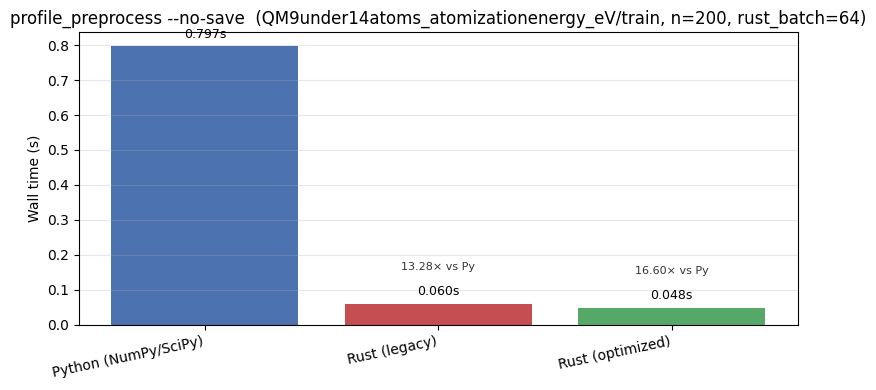

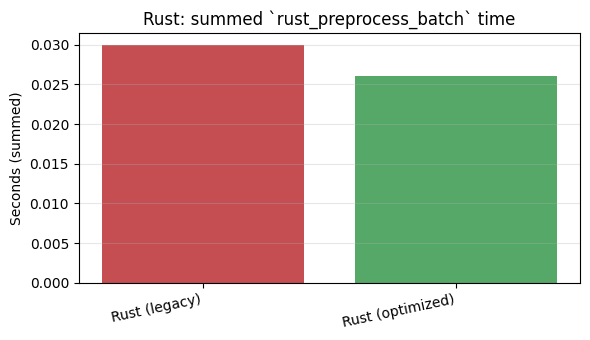

Rust optimized vs Rust legacy (script wall): 1.250× (higher = faster opt)


In [18]:
import matplotlib.pyplot as plt

labels = df["label"].tolist()
walls = df["wall_s"].astype(float).tolist()
palette = ["#4C72B0", "#C44E52", "#55A868"]
colors = [palette[i % len(palette)] for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, walls, color=colors)
ax.set_ylabel("Wall time (s)")
ax.set_title(
    f"profile_preprocess --no-save  ({DATASET}/{SPLIT}, n={LIMIT}, "
    f"rust_batch={RUST_BATCH_SIZE})"
)
ax.grid(True, axis="y", alpha=0.3)
mx = max(walls) if walls else 1.0
for b, w in zip(bars, walls):
    ax.text(
        b.get_x() + b.get_width() / 2,
        w + mx * 0.02,
        f"{w:.3f}s",
        ha="center",
        va="bottom",
        fontsize=9,
    )

if walls:
    py_wall = walls[0]
    for i in range(1, len(walls)):
        w = walls[i]
        if w and w > 0:
            ax.annotate(
                f"{py_wall / w:.2f}× vs Py",
                xy=(i, w),
                xytext=(i, w + mx * 0.12),
                ha="center",
                fontsize=8,
                color="#333",
            )

plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

# Rust-only: native batch step
col = "step__rust_preprocess_batch"
rust_df = df[df["backend"].isin(["rust", "rust-legacy"])]
if col in rust_df.columns and rust_df[col].notna().any() and len(rust_df) > 0:
    fig2, ax2 = plt.subplots(figsize=(6, 3.5))
    rcolors = ["#C44E52", "#55A868"][: len(rust_df)]
    ax2.bar(rust_df["label"], rust_df[col], color=rcolors)
    ax2.set_ylabel("Seconds (summed)")
    ax2.set_title("Rust: summed `rust_preprocess_batch` time")
    ax2.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=12, ha="right")
    plt.tight_layout()
    plt.show()

if len(rust_df) >= 2:
    w_leg = float(rust_df.loc[rust_df["backend"] == "rust-legacy", "wall_s"].iloc[0])
    w_opt = float(rust_df.loc[rust_df["backend"] == "rust", "wall_s"].iloc[0])
    if w_opt > 0:
        print(f"Rust optimized vs Rust legacy (script wall): {w_leg / w_opt:.3f}× (higher = faster opt)")

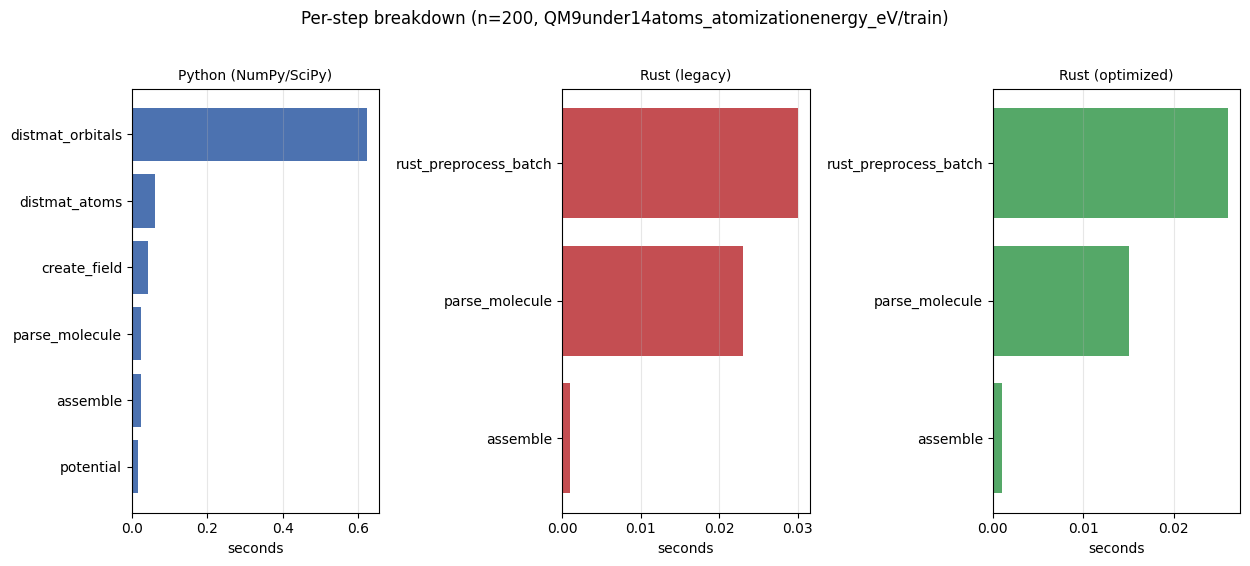

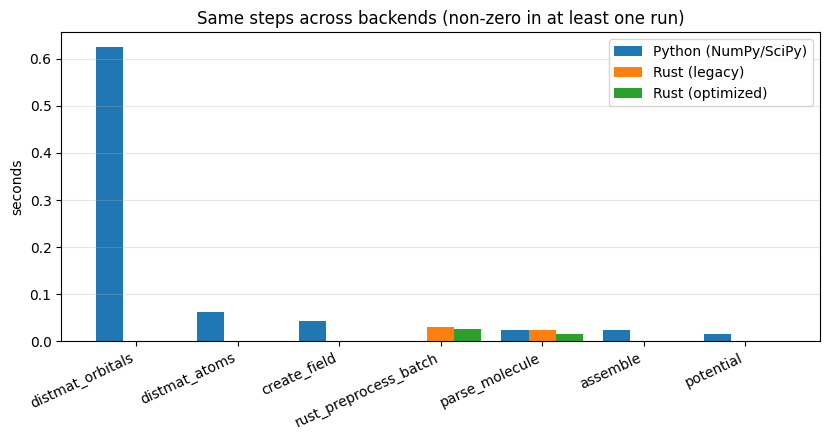

In [19]:
# Per-step breakdown (seconds from profile_preprocess "Per-step totals")
import matplotlib.pyplot as plt
import numpy as np

step_cols = [c for c in df.columns if c.startswith("step__")]
if not step_cols:
    print("No step__* columns — run the benchmark cell first.")
else:
    n = len(df)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 5.5), sharey=False)
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, df.iterrows()):
        names = []
        vals = []
        for c in sorted(step_cols, key=lambda x: -(row[x] if pd.notna(row[x]) else 0.0)):
            v = row[c]
            if pd.isna(v) or float(v) <= 0:
                continue
            names.append(c.replace("step__", ""))
            vals.append(float(v))
        if not vals:
            ax.text(0.5, 0.5, "no steps", ha="center", va="center")
            ax.set_axis_off()
            continue
        names = names[::-1]
        vals = vals[::-1]
        cmap = {"numpy": "#4C72B0", "rust-legacy": "#C44E52", "rust": "#55A868"}
        ax.barh(names, vals, color=cmap.get(row["backend"], "#888888"))
        ax.set_xlabel("seconds")
        ax.set_title(row["label"], fontsize=10)
        ax.grid(True, axis="x", alpha=0.3)
    fig.suptitle(
        f"Per-step breakdown (n={LIMIT}, {DATASET}/{SPLIT})",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # Grouped: same step keys across runs (union of step names, non-zero any row)
    short = [c.replace("step__", "") for c in step_cols]
    union_steps = []
    for s in short:
        if any(
            (pd.notna(df.iloc[i][f"step__{s}"]) and float(df.iloc[i][f"step__{s}"]) > 0)
            for i in range(len(df))
        ):
            union_steps.append(s)
    union_steps.sort(
        key=lambda s: max(
            float(df.iloc[i][f"step__{s}"]) if pd.notna(df.iloc[i][f"step__{s}"]) else 0.0
            for i in range(len(df))
        ),
        reverse=True,
    )

    if union_steps:
        fig2, ax2 = plt.subplots(figsize=(max(8, 1.2 * len(union_steps)), 4.5))
        x = np.arange(len(union_steps))
        w = 0.8 / max(1, n)
        for i, (_, row) in enumerate(df.iterrows()):
            offs = (i - (n - 1) / 2) * w
            series = [
                float(row[f"step__{s}"]) if pd.notna(row[f"step__{s}"]) else 0.0
                for s in union_steps
            ]
            ax2.bar(x + offs, series, width=w, label=row["label"])
        ax2.set_xticks(x)
        ax2.set_xticklabels(union_steps, rotation=25, ha="right")
        ax2.set_ylabel("seconds")
        ax2.set_title("Same steps across backends (non-zero in at least one run)")
        ax2.legend()
        ax2.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

Full stdout/stderr for the last run is in `raw_logs` (all three keys). Example: `print(raw_logs['Rust (legacy)'][-2500:])`.